In [62]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn import linear_model
import seaborn as sns
import random 
import statistics 
import math 
import scipy as sc
from scipy.stats import chisquare
from collections import Counter

random.seed(42)

### Part 1: A discrete-time model

In this project, we will work with the following Markov model.
The model follows women after they had their breast tumor removed. The cancer may reappear close to the removed tumor. This is called local recur- rence, and the woman enters state 2. The cancer may also reappear distant from where it was operated. This is called distant metastatis. Both things may also occour. Death can occur from any state. In this model, once the death state has been entered, it can never be left again. This means the simulation should be terminated once this state has been reached.

### Task 1

Use the following probability matrix:

In [63]:
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
               [0, 0.986, 0.005, 0.004, 0.005],
               [0, 0, 0.992, 0.003, 0.005],
               [0, 0, 0, 0.991, 0.009],
               [0, 0, 0, 0, 1]])

Assume that one time step equals one month. Simulate 1000 women, all starting in state 1, until death. Summarize the lifetime distribution of the women, after surgery, for example using a histogram. In what proportion of women does the cancer eventually reappear, locally?

In this assignment we want to simulate 1000 women who have had breast cancer and have undergone surgery. There are 5 possible states they can get into after surgery.

• State 1: Healthy after removal of the tumor,

• State 2: Local recurrence of the cancer,

• State 3: Distant recurrence of the cancer,

• State 4: Both local and distant recurrence of the cancer,

• State 5: Death.

In [64]:
n_women = 1000
survival_distribution = []
cancer_local_count = 0
states = []

In [65]:
for _ in range(n_women):
    state = 0 
    survivaltime = 0
    had_local = False 

    while state != 4: 
        state = np.random.choice(range(5), p=P[state])
        survivaltime += 1

        if state == 1 or state == 3:  
            had_local = True
            
    if had_local:
        cancer_local_count += 1
        
    states.append(state)
    survival_distribution.append(survivaltime)

Text(0.5, 1.0, 'Lifetime Distribution of Women after Surgery')

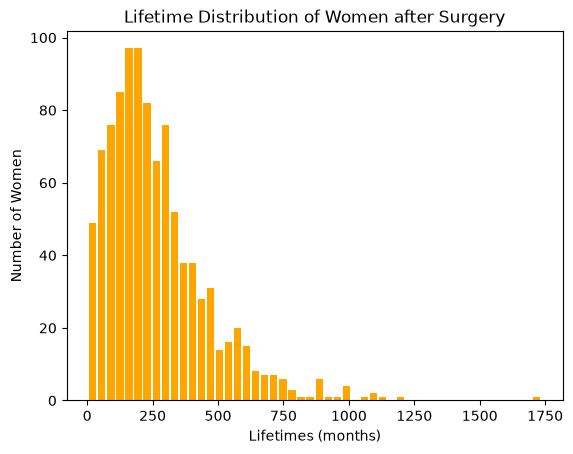

In [66]:
plt.hist(survival_distribution, bins=50, rwidth=0.8, color="orange")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')

In [67]:
reapear_locally = cancer_local_count/n_women
print("Median of lifetime distribution of women after Surgery = ",np.median(survival_distribution) )
print("Proportion of women where cancer reapear locally = ", reapear_locally)


Median of lifetime distribution of women after Surgery =  221.0
Proportion of women where cancer reapear locally =  0.702


The histogram shows the distribution of how many months women survive after surgery. The plot is right skewed, meaning that most women survive shorter than the median. We can also conclude that the proportion of women where cancer reappears locally is approx. 70%.

#### Task 2
In your simulations, what is the distribution over the states at t = 120? Does this correspond to what we expect? Answer the question using an appropriate statistical test.

Using the probability distribution over the states at time t: $p_{t} = p_{t}(P^{0})$, we expect everyone to be in state 0 (Surgery) at first, as the experiment starts after surgery. We thereby define $p_{0} = [1, 0, 0, 0, 0]$

In [68]:
def time_state_distribution(n, t):
    survival_distribution = []
    states = []

    for _ in range(n):
        state = 0 
        survivaltime = 0

        while state != 4 and survivaltime < t: 
            state = np.random.choice(range(5), p=P[state])
            survivaltime += 1
            
        states.append(state)
        survival_distribution.append(survivaltime)
    
    return survival_distribution, states

In [69]:
t = 120
survival_time, n_states = time_state_distribution(n_women, t)

Text(0.5, 1.0, 'State')

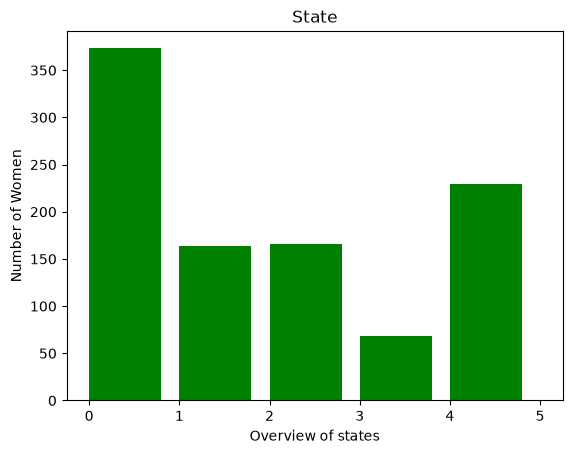

In [70]:
plt.hist(n_states, bins=range(len(P)+1), color="green",  width=0.8);
plt.xlabel('Overview of states')
plt.ylabel('Number of Women')
plt.title('State')

In [71]:
states_count = np.array(list(Counter(sorted(n_states)).values()))
observed = [float(x) / float(n_women) for x in states_count]

print("Observed probabilities per state =", observed)

Observed probabilities per state = [0.373, 0.164, 0.166, 0.068, 0.229]


We can conclude that it is most likely to be at state 1 (surgery) or 5 (Death).

We use the probability distribution over the states at time t: $p_{t} = p_{t}(P^{0})$ in order to find the expected probability distribution of states. We expect everyone to be in state 0 (Surgery) at first, as the experiment starts after surgery. We thereby define $p_{0} = [1, 0, 0, 0, 0]$

In [72]:
p_0 = np.array([1, 0, 0, 0, 0])
t = 120
p_t = np.dot(p_0, np.linalg.matrix_power(P, t))

print("Distribution over the states at t =", t,":")
print(p_t)

Distribution over the states at t = 120 :
[0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]


We can conclude that according to the theoretical it is most likely to be at state 1 (surgery) or 5 (death). The 2 highest are still states 1,  5 as in our simulated example, therefore the simulated and theoretical are very similar. There is no big fluctuation in our simulated and theoretical distribution as seen below

We now use a $\chi^2$  test  as our statistical test performed by finding the test statistic using the following expression:
$T = \sum_{i=1}^{n_{classes}}\cfrac{(n_{observed,i}-n_{expected,i})^2}{n_{expected,i}}$
The statistic is to be evaluated with the distribution with df degrees of freedom. df is generally $n_{classes} − 1 − m$ where m is the number of estimated parameters.

After this then find the p-value using the  following expression:

$P(\chi^2_df ≥ T)$

In [73]:
expected_count = n_women * p_t


chi2_stat, chi2_pvalue = chisquare(states_count, expected_count)

print("Chi-square test-statistics =", chi2_stat)
print("Chi-square p-values =", chi2_pvalue)

Chi-square test-statistics = 2.188623122366914
Chi-square p-values = 0.7011126735781441


The p value > 0.05 means that we can accept the hypothesis that our simulated observed values follow the theoretical values.

#### Task 3
Does your simulated lifetimes follow this distribution?

In [74]:
t = 1000
survival_dist, n_states = time_state_distribution(n_women, t)

In [75]:
Ps = P[:4,:4]
ps = P[:-1, -1]
Ps, ps

(array([[0.9915, 0.005 , 0.0025, 0.    ],
        [0.    , 0.986 , 0.005 , 0.004 ],
        [0.    , 0.    , 0.992 , 0.003 ],
        [0.    , 0.    , 0.    , 0.991 ]]),
 array([0.001, 0.005, 0.005, 0.009]))

In [76]:
pi = np.array([1, 0, 0, 0])
I = np.eye(4)

P_T_Expected = []
E_T_Expected = np.dot(np.dot(pi, np.linalg.inv(I - Ps)), np.ones(4))

for i in range(t): 
    P_T_Expected.append(np.dot(np.dot(pi, np.linalg.matrix_power(Ps, i)), ps))



Text(0.5, 1.0, 'Lifetime Distribution of Women after Surgery')

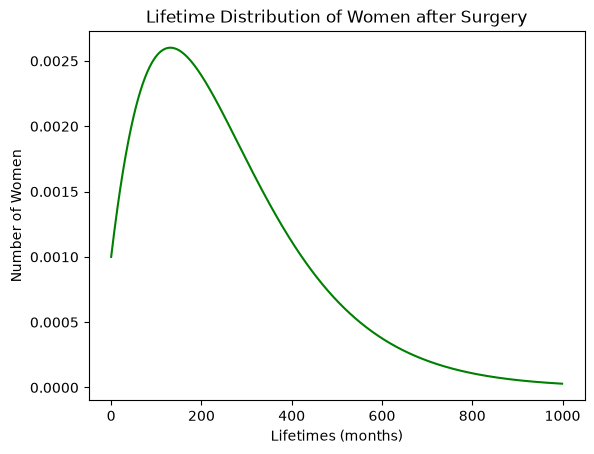

In [77]:
plt.plot(P_T_Expected, color="green")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')

In [78]:
print("Simulated Mean Lifetime =", np.mean(survival_dist))
print("Theoretical Mean Lifetime =", E_T_Expected)

Simulated Mean Lifetime = 263.03
Theoretical Mean Lifetime = 262.3716153127931


In [79]:
t = 1000
survival_time, n_states = time_state_distribution(n_women, t)

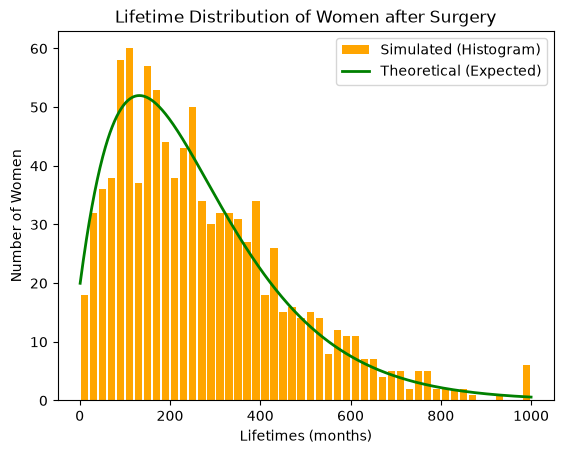

In [80]:
# 1. Plot the histogram and capture the 'bins' array it generates
counts, bins, patches = plt.hist(survival_time, bins=50, rwidth=0.8, color="orange", label="Simulated (Histogram)")

# 2. Calculate the width of a single bin
bin_width = bins[1] - bins[0]

# 3. Scale the theoretical distribution
# Convert P_T_Expected to a numpy array if it isn't already
P_T_Expected = np.array(P_T_Expected)

# Multiply by n_women (to get counts) AND bin_width (to match the histogram's grouping)
scaled_theoretical = P_T_Expected * n_women * bin_width

# 4. Plot the scaled theoretical line
# Create an x-axis array for the months (1 to 1000) to align the plot correctly
months_x = np.arange(1, len(scaled_theoretical) + 1)
plt.plot(months_x, scaled_theoretical, color="green", linewidth=2, label="Theoretical (Expected)")

# 5. Add labels and legend
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')
plt.legend()

plt.show()

In [81]:
P_T_Expected = np.array(P_T_Expected)
expected_counts = P_T_Expected * n_women

# Calculate the observed counts from your simulated survival_dist
# We use bins from 1 to t+1 so that the indices strictly align with the months 1 to 1000
observed_counts, _ = np.histogram(survival_dist, bins=np.arange(1, t + 2))

obs_binned = []
exp_binned = []

curr_obs = 0
curr_exp = 0

for obs, exp in zip(observed_counts, expected_counts):
    curr_obs += obs
    curr_exp += exp
    
    # Once the expected count reaches 5 or more, append to our grouped bins and reset
    if curr_exp >= 5:
        obs_binned.append(curr_obs)
        exp_binned.append(curr_exp)
        curr_obs = 0
        curr_exp = 0

# Add any remaining tail counts (that didn't reach 5) to the very last bin
if curr_exp > 0:
    obs_binned[-1] += curr_obs
    exp_binned[-1] += curr_exp

# Convert back to numpy arrays
obs_binned = np.array(obs_binned)
exp_binned = np.array(exp_binned)

# Normalize expected counts so their sum perfectly matches the sum of observed counts
# (scipy.stats.chisquare requires the sums to be mathematically identical)
exp_binned = exp_binned * (np.sum(obs_binned) / np.sum(exp_binned))

# Perform the Chi-Square goodness-of-fit test
chi2_stat, chi2_pvalue = chisquare(f_obs=obs_binned, f_exp=exp_binned)

print("Chi-square test-statistic =", chi2_stat)
print("Chi-square p-value =", chi2_pvalue)

Chi-square test-statistic = 180.4637228808354
Chi-square p-value = 0.29511988179903803


The high p-value suggests that the simulated lifetimes follow this distribution

## Task 4

In [103]:
# A function is created that takes number of samples as input
def expected_lifetime_after_surgery(n_women): 

    
    samples = 0
    accept_reject = []
    survival_time = []

# while the accepcted samples account for less than 1000, resampling continues.
    while samples < n_women:  
    
        state = 0 
        time = 0
    
# The initial acceptance/rejection phase
        # loop through states which is not 4
        while state != 4 and time < 12: 
            state = np.random.choice(range(5), p=P[state])
            time += 1
            
            if state in [1 , 2]:
                while state != 4: 
                    state = np.random.choice(range(5), p=P[state])
                    time += 1
                samples += 1
        
                survival_time.append(time)

    expected_lifetime = np.mean(survival_time)


            
    return expected_lifetime, survival_time


In [104]:
n_women = 1000
expected_lifetime = expected_lifetime_after_surgery(n_women)
print("Expected lifetime after surgery:", expected_lifetime[0], "months.")

Expected lifetime after surgery: 181.023 months.


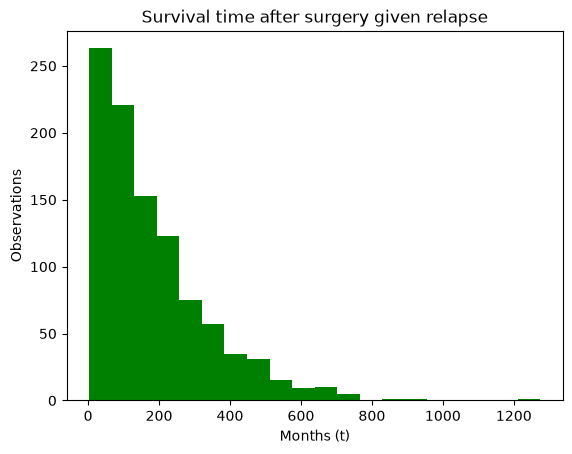

In [106]:
plt.hist(expected_lifetime[1], bins = 20, color="green")
plt.xlabel('Months (t)')
plt.ylabel('Observations')
plt.title('Survival time after surgery given relapse')
plt.show()

The model shows the expected lifetime for a woman who has survived the first 12 months after breast cancer surgery but has had the cancer reappear again within 12 months. It can be seen from the acceptance/rejection simulation of 1000 samples, that the expected lifetime post operation is roughly 180 months. The plot shows how the majority of women who pass away following the reappearance of the cancer die early

## Task 5

What fraction of women die within the first 350 months? Answer this by simulating 200 women, and record the fraction. Do this 100 times. Use control variates to reduce the variance. How large a reduction in variance do you see, using control variates, as opposed to the crude Monte Carlo estimator?


To apply control variates to reduce the estimator's variance in the given exercise, we must identify a suitable control variate correlated with the variable of interest. In this case, the variable of interest is the the mean lifetime after surgery.
Given the knowledge of control variates, we can calculate the optimal value of c (the coefficient for the control variate) using the formula: $c = -\cfrac{Cov(X, Y)}{ Var(Y)}$. We use the fraction of death as X and the control variate (the mean survival time) as Y.

In [116]:
def calculate_control_variate(fraction_death, control_variate):
    covariance = np.mean((fraction_death - np.mean(fraction_death)) * (control_variate - np.mean(control_variate)))
    variance = np.mean((control_variate - np.mean(control_variate)) ** 2)
    c = -covariance / variance if variance != 0 else 0
    return c

Now we implement the main function. This function is structured as in part 2, but instead of counting the distribution in each state, we now find the fraction of women who die within the first 350 months. We use the mean lifetime after surgery as the control variate and finds z from the given formula $Z=X+c(Y − μ_y)$ where X is the fraction of death women, c is the calculate control variate and Y is the control variate survival_time and $μ_y$ is the mean of the control variate.

In [ ]:
def women_death_cv(n_women, t):
    survival_times = []
    deaths_within_350 = 0
    control_variate = []

    for _ in range(n_women):
        state = 0
        survival_time = 0

        while state != 4 and survival_time < t:
            state = np.random.choice(range(5), p=P[state])
            survival_time += 1

        survival_times.append(survival_time)

        if state == 4:
            deaths_within_350 += 1

        # store control variate as the mean lifetime after surgery
        control_variate.append(np.mean(survival_times))  

    #find fraction of death within   
    fraction_death = deaths_within_350 / n_women

    # Apply control variates
    control_variate_mean = np.mean(control_variate)

    c = calculate_control_variate(fraction_death, control_variate) # Choose the optimal c value

    # Compute the control variate adjusted fraction of deaths
    z = fraction_death + c * (control_variate - control_variate_mean)
    
    adjusted_fraction_death = np.mean(z)

    return adjusted_fraction_death, np.var(z)

In [114]:
n_simulations = 100
n_women = 200
t = 350

In [115]:
fractions_of_deaths = []
variances = []

for _ in range(n_simulations):
    fraction_death, variance = women_death_cv(n_women, t)
    fractions_of_deaths.append(fraction_death)
    variances.append(variance)

mean_fraction_death = np.mean(fractions_of_deaths)
variance_cv = np.mean(variances)
variance_without_cv = np.var([women_death_cv(n_women, t) for _ in range(n_simulations)])
variance_reduction = 1 - variance_cv / variance_without_cv


In [113]:
print("Estimated fraction of women who die within the first 350 months:", mean_fraction_death)
print("Variance reduction using control variates:", variance_reduction)
print("Variance without control variate:", variance_without_cv)
print("Variance with control variate:", variance_cv )

Estimated fraction of women who die within the first 350 months: 0.7699999999999999
Variance reduction using control variates: 1.0
Variance without control variate: 0.14436875
Variance with control variate: 1.479114197289397e-32


## Task 6

For the report, consider the following questions: What assumptions underlie
the discrete time Markov chain model? Are those assumptions realistic? How
may we relax some of these assumptions, possibly at the cost of increased
model complexity?